In [52]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
from sklearn.impute import KNNImputer
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, RocCurveDisplay, 
                             ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [53]:
dataset = {
    "train": pd.read_excel("data/train.xlsx"),
    "test": pd.read_excel("data/train.xlsx")
}

In [54]:
dataset["train"].head()

,ID,Target,P1,P2,P3,P4,P5,P6,P7,P8,...,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31
0,283,1,0.0,NaN,NaN,10,0,1.02273,1.01608,1.55268,...,831.68333,783.81667,171.33333,818.15000,0.62772,0.13333,0.00000,6.41893,0.97122,6.41893
1,342,0,0.0,30.00000,6.80153,0,0,1.00000,1.65348,1.14852,...,195.13889,168.30000,81.00000,NaN,6.32407,0.26667,0.33333,NaN,1.60714,3.44800
2,631,0,0.0,30.00000,9.60267,0,0,1.00000,0.84143,NaN,...,226.10556,207.41667,110.00000,184.49444,2.25635,0.00000,0.06667,NaN,0.75000,8.08000
3,1165,0,0.0,30.33333,15.32553,0,0,0.98901,0.88114,NaN,...,567.53889,441.52778,194.00000,625.32222,2.74469,0.13333,0.40000,13.50400,0.98119,13.50400
4,1469,0,0.0,28.00000,7.54133,0,0,0.92857,1.21447,0.60138,...,154.80556,86.64444,71.66667,53.45000,0.91130,0.46667,0.40000,NaN,0.40171,3.44800


In [55]:
dataset["train"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      10000 non-null  int64  
 1   Target  10000 non-null  int64  
 2   P1      10000 non-null  float64
 3   P2      8492 non-null   float64
 4   P3      8523 non-null   float64
 5   P4      10000 non-null  int64  
 6   P5      10000 non-null  int64  
 7   P6      10000 non-null  float64
 8   P7      10000 non-null  float64
 9   P8      8482 non-null   float64
 10  P9      10000 non-null  float64
 11  P10     10000 non-null  float64
 12  P11     10000 non-null  float64
 13  P12     10000 non-null  float64
 14  P13     10000 non-null  float64
 15  P14     10000 non-null  float64
 16  P15     10000 non-null  float64
 17  P16     8475 non-null   float64
 18  P17     10000 non-null  float64
 19  P18     10000 non-null  float64
 20  P19     10000 non-null  float64
 21  P20     10000 non-null  float64
 22 

Let's check if there are duplicate rows in the data:

In [56]:
dataset["train"] = dataset["train"].drop_duplicates()
dataset["train"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      10000 non-null  int64  
 1   Target  10000 non-null  int64  
 2   P1      10000 non-null  float64
 3   P2      8492 non-null   float64
 4   P3      8523 non-null   float64
 5   P4      10000 non-null  int64  
 6   P5      10000 non-null  int64  
 7   P6      10000 non-null  float64
 8   P7      10000 non-null  float64
 9   P8      8482 non-null   float64
 10  P9      10000 non-null  float64
 11  P10     10000 non-null  float64
 12  P11     10000 non-null  float64
 13  P12     10000 non-null  float64
 14  P13     10000 non-null  float64
 15  P14     10000 non-null  float64
 16  P15     10000 non-null  float64
 17  P16     8475 non-null   float64
 18  P17     10000 non-null  float64
 19  P18     10000 non-null  float64
 20  P19     10000 non-null  float64
 21  P20     10000 non-null  float64
 22 

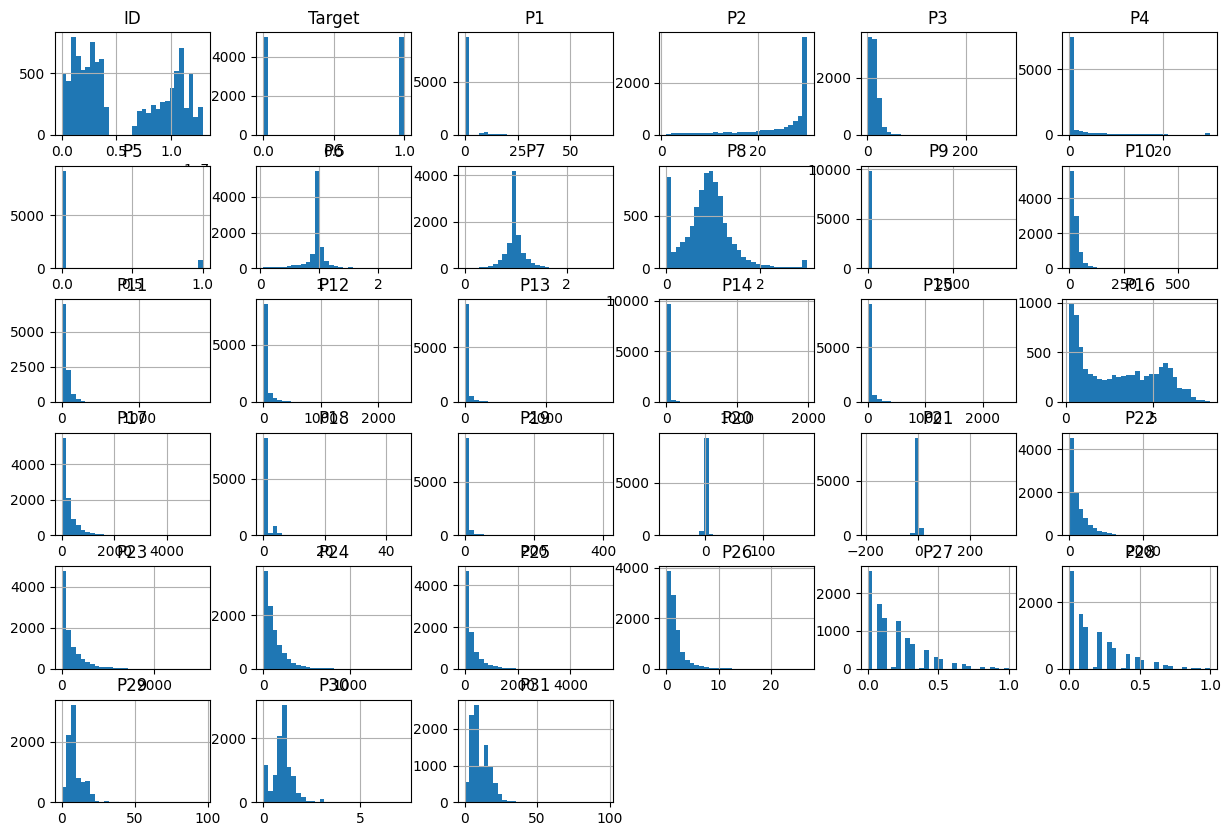

In [57]:
dataset["train"].hist(bins=30, figsize=(15, 10))
plt.show()

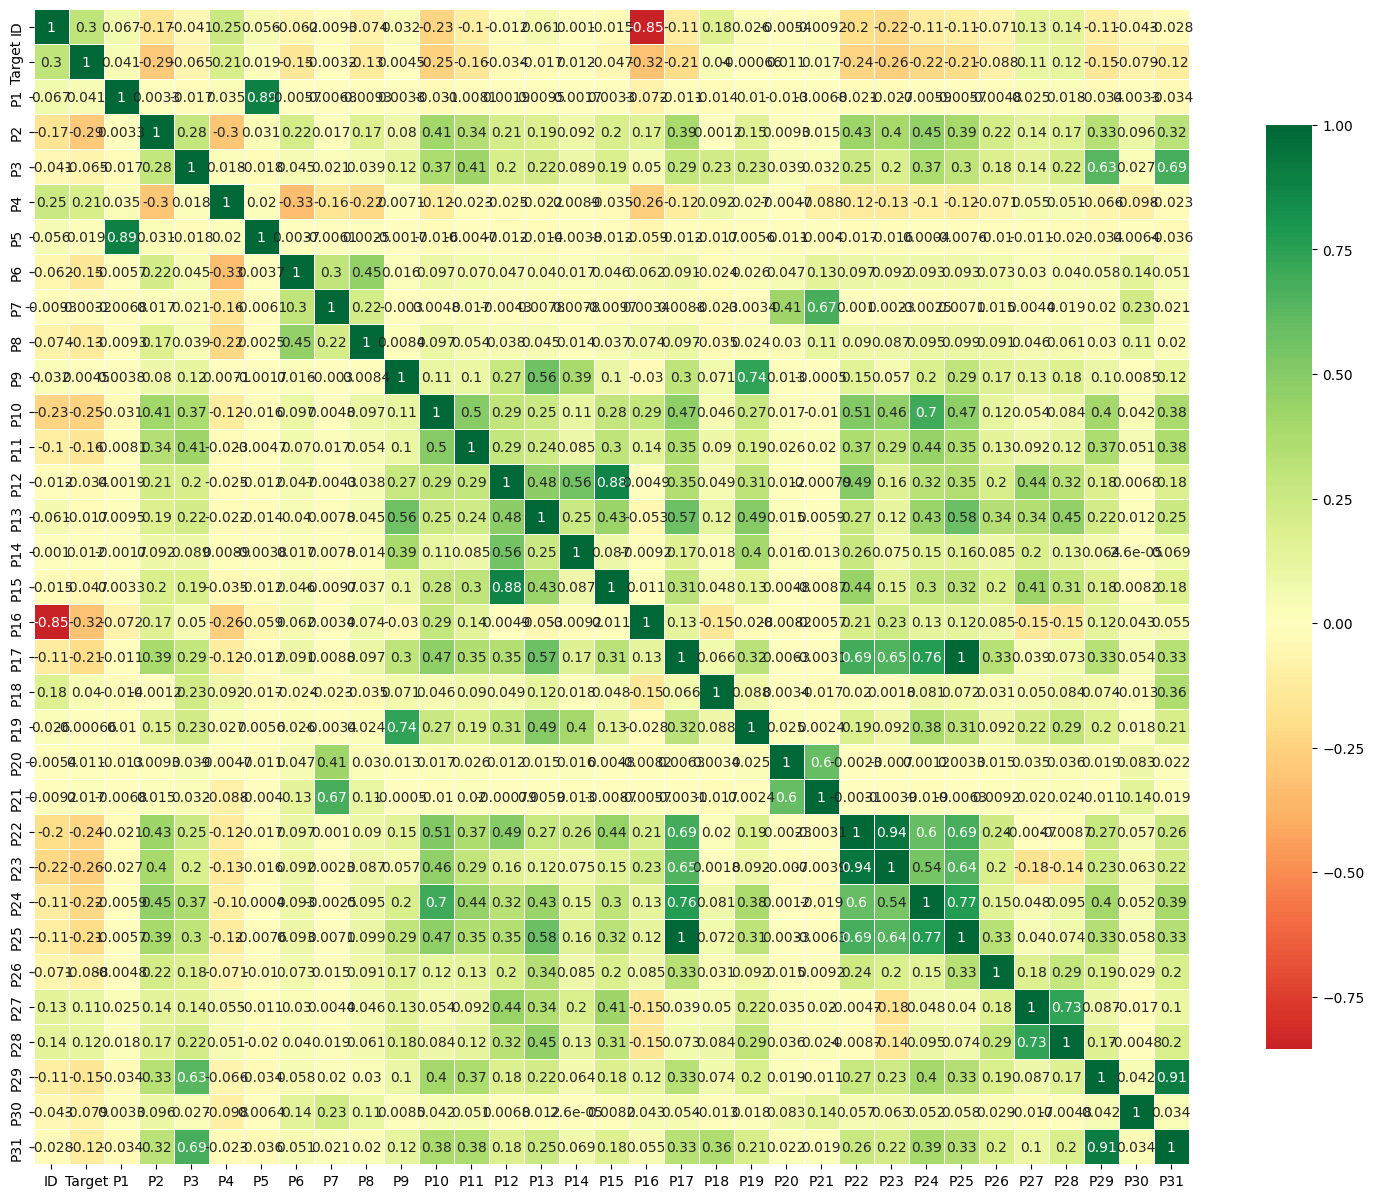

In [58]:
corr = dataset["train"].corr()
fig, ax = plt.subplots(figsize=(20,15))
heatmap = sb.heatmap(corr,
                     annot=True,
                     annot_kws={'size': 10},
                     cmap='RdYlGn',
                     center=0,
                     square=True,
                     linewidths=0.5,
                     cbar_kws={'shrink': 0.8},
                     fmt='.2g')

plt.show()

As can be seen from the correlation matrix, there are attributes with strong correlation between each other. For example, columns P25 and P17, P29 and P31 have strong positive correlation, columns P16 and ID have strong negative correlation. I think we should just discard one feature from these pairs because they duplicate each other's information. I think it's better to drop features with little correlation with the target, such as P7, P9, P20 and others, because they don't carry much useful information and will just confuse our models.

In [59]:
columns_to_drop = ["P25", "P16", "P29", "P23", "P1", "P5", "P7", "P9", "P12", 
                   "P13", "P14", "P15", "P18", "P19", "P20", "P21", "P24", "P27"]

dataset_dropped = {
    data_type: data.drop(columns=columns_to_drop)
    for data_type, data in dataset.items()
}

Our new correlation matrix

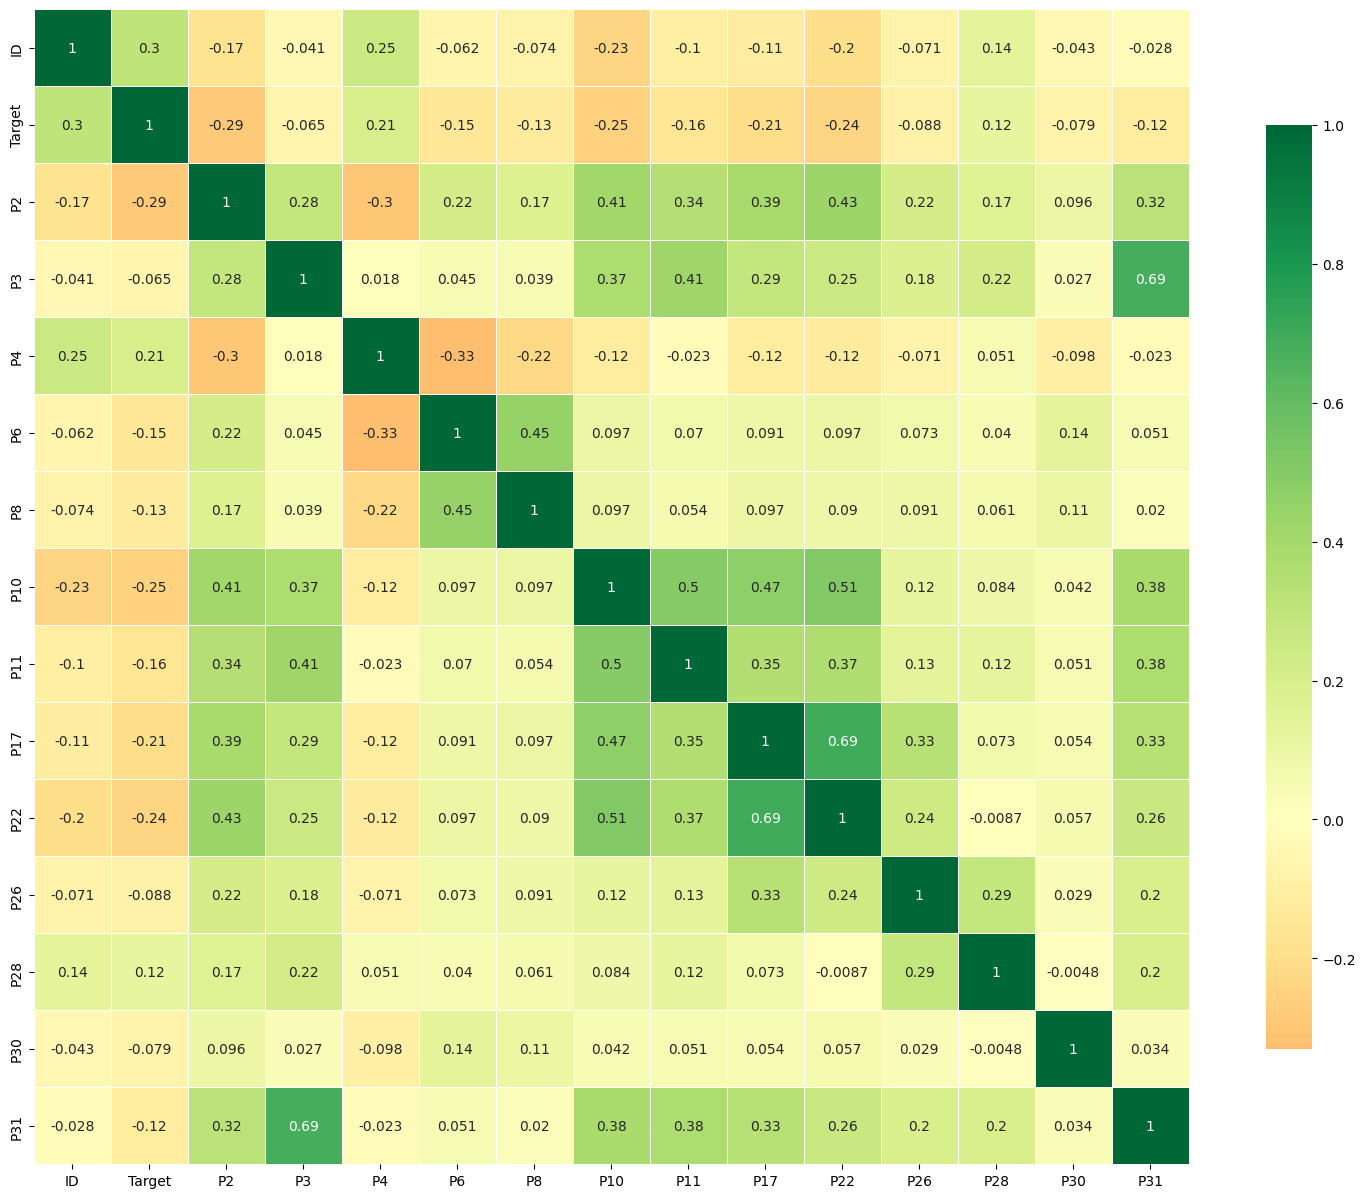

In [60]:
corr = dataset_dropped["train"].corr()
fig, ax = plt.subplots(figsize=(20,15))
heatmap = sb.heatmap(corr,
                     annot=True,
                     annot_kws={'size': 10},
                     cmap='RdYlGn',
                     center=0,
                     square=True,
                     linewidths=0.5,
                     cbar_kws={'shrink': 0.8},
                     fmt='.2g')

plt.show()

In [61]:
dataset_dropped["train"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      10000 non-null  int64  
 1   Target  10000 non-null  int64  
 2   P2      8492 non-null   float64
 3   P3      8523 non-null   float64
 4   P4      10000 non-null  int64  
 5   P6      10000 non-null  float64
 6   P8      8482 non-null   float64
 7   P10     10000 non-null  float64
 8   P11     10000 non-null  float64
 9   P17     10000 non-null  float64
 10  P22     10000 non-null  float64
 11  P26     10000 non-null  float64
 12  P28     10000 non-null  float64
 13  P30     10000 non-null  float64
 14  P31     10000 non-null  float64
dtypes: float64(12), int64(3)
memory usage: 1.1 MB


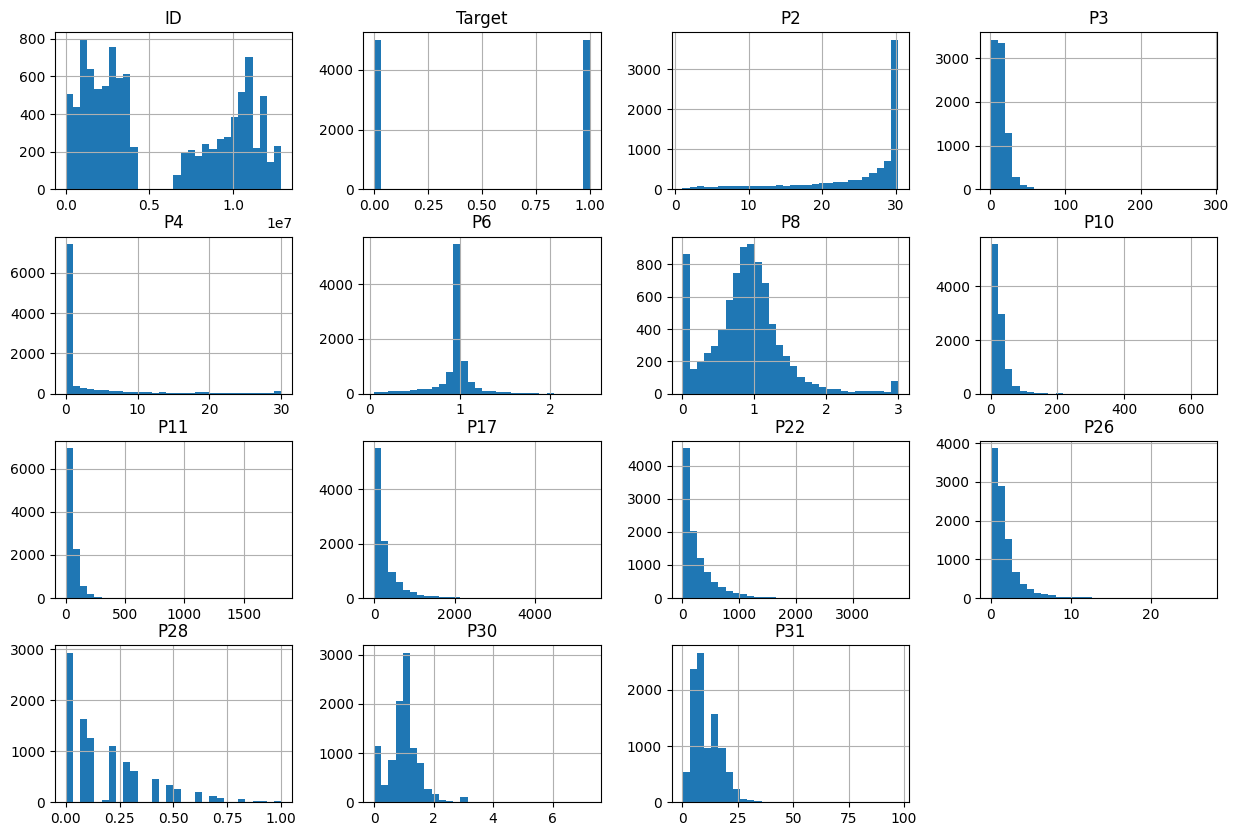

In [62]:
dataset_dropped["train"].hist(bins=30, figsize=(15, 10))
plt.show()

In [63]:
targets = {
    data_type: data["Target"]
    for data_type, data in dataset_dropped.items()
}

features = {
    data_type: data.drop(columns=["Target"])
    for data_type, data in dataset_dropped.items()
}

As we can see, we have a binary classification task. And classes is perfectly balanced:

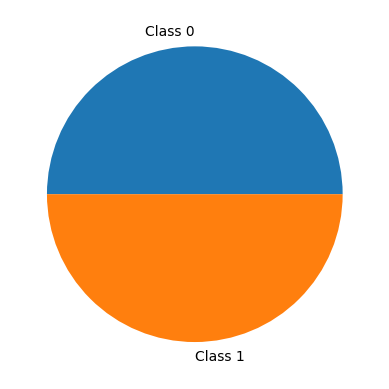

In [64]:
labels = ['Class 0', 'Class 1']
sizes = targets["train"].value_counts()

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels)
plt.show()

Let's us fill our Nan values using nearest neighbours algorithm.

In [65]:
imputer = KNNImputer(n_neighbors=3)
columns = features["train"].columns

features_filled = {
    "train": pd.DataFrame(imputer.fit_transform(features["train"]), columns=columns),
    "test": pd.DataFrame(imputer.transform(features["test"]), columns=columns)
}
features_filled["train"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      10000 non-null  float64
 1   P2      10000 non-null  float64
 2   P3      10000 non-null  float64
 3   P4      10000 non-null  float64
 4   P6      10000 non-null  float64
 5   P8      10000 non-null  float64
 6   P10     10000 non-null  float64
 7   P11     10000 non-null  float64
 8   P17     10000 non-null  float64
 9   P22     10000 non-null  float64
 10  P26     10000 non-null  float64
 11  P28     10000 non-null  float64
 12  P30     10000 non-null  float64
 13  P31     10000 non-null  float64
dtypes: float64(14)
memory usage: 1.1 MB


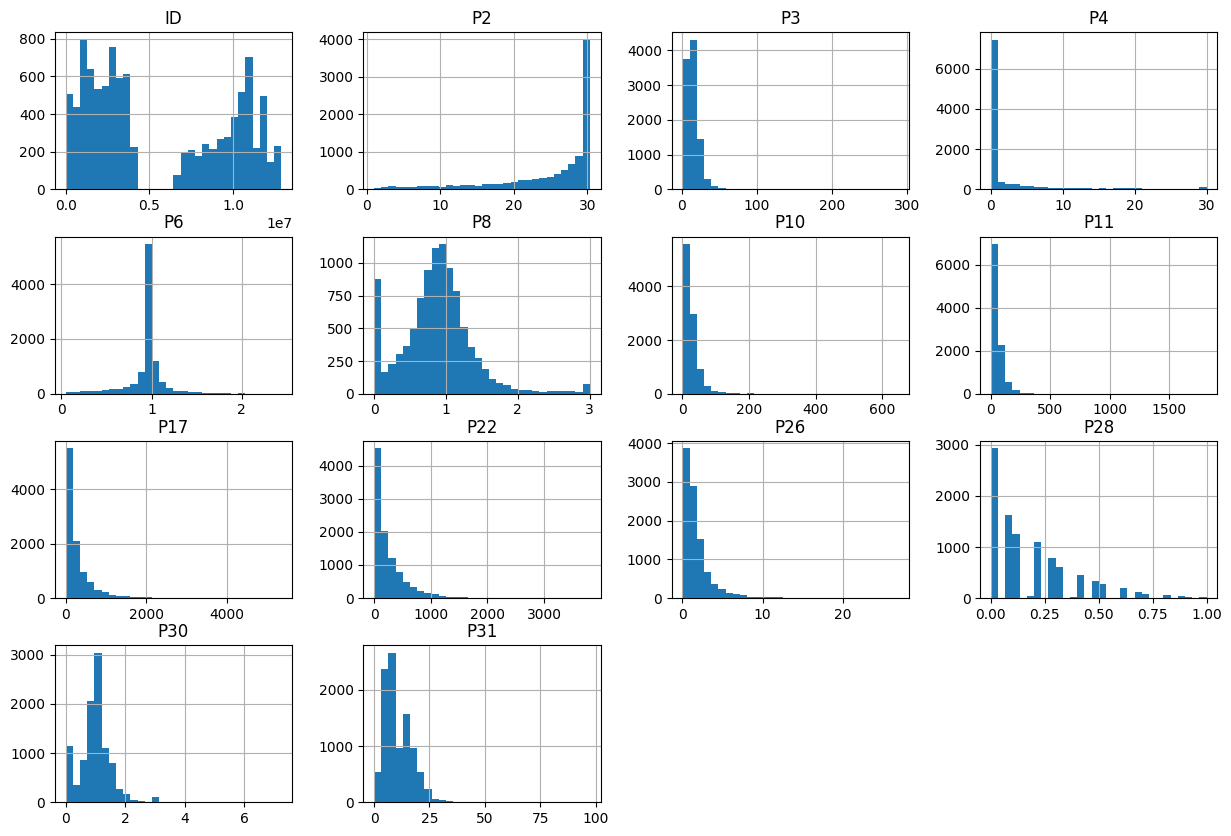

In [66]:
features_filled["train"].hist(bins=30, figsize=(15, 10))
plt.show()

Let's check if there are outliers in our data.

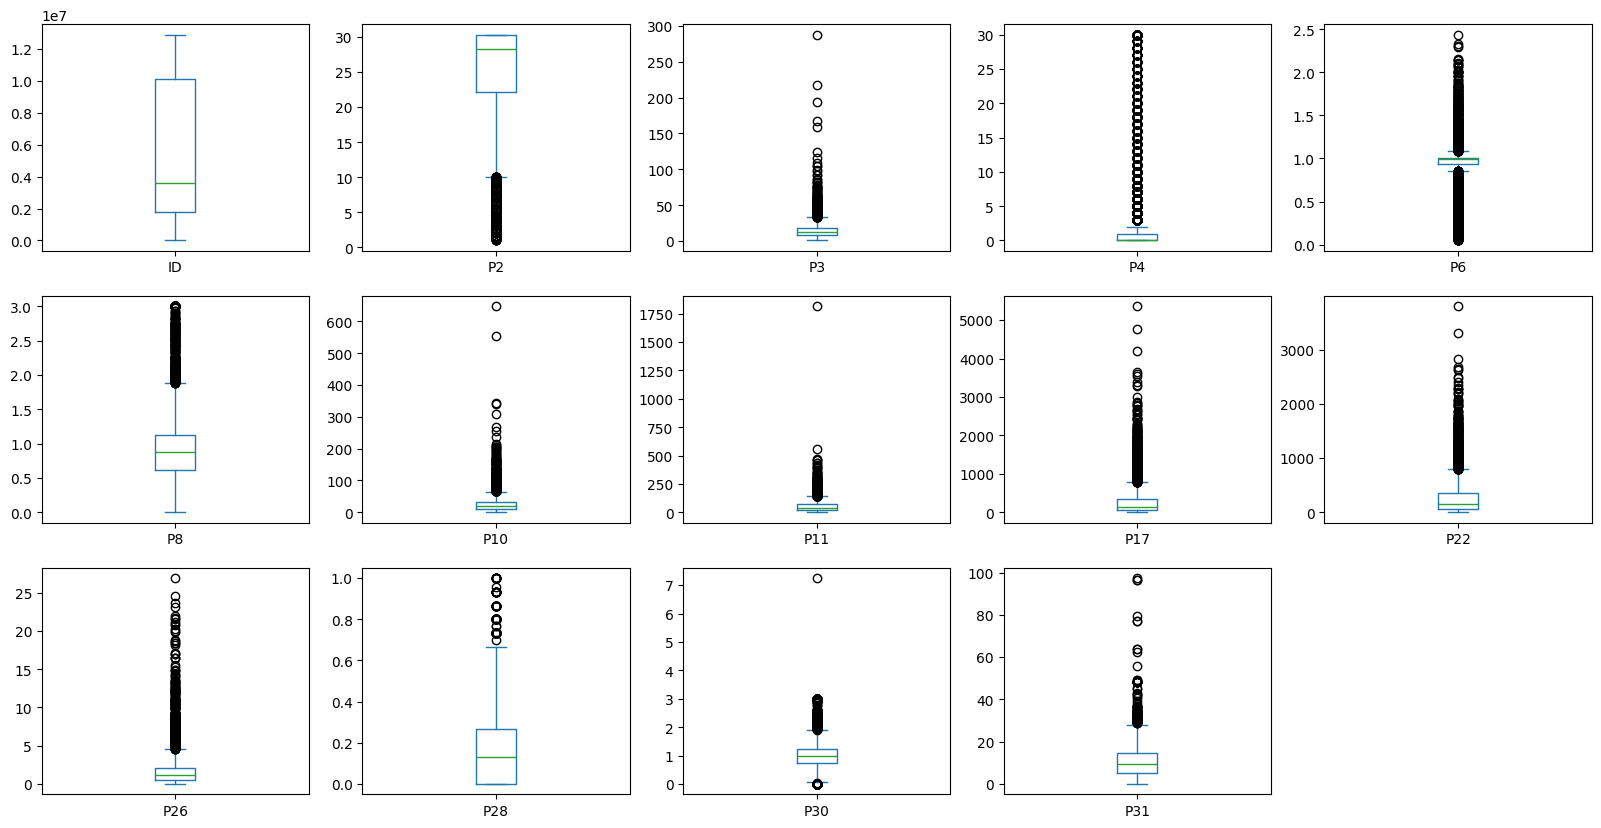

In [67]:
features_filled["train"].plot(kind='box', subplots=True, layout=(3, 5), figsize=(20, 10))
plt.show()

Removing the most significant outliers, with interval of 6 interquantile range.

In [68]:
columns_to_remove_ouliers = ["P3", "P6", "P10", "P11", "P17", "P22", "P26", "P30", "P31"]

no_outliers_features = copy.deepcopy(features_filled["train"])
no_outliers_targets = copy.deepcopy(targets["train"])

for col in columns_to_remove_ouliers:
        first_quantile = no_outliers_features[col].quantile(0.25)
        third_quantile = no_outliers_features[col].quantile(0.75)
        IQR = third_quantile - first_quantile
        lower_bound = first_quantile - 6 * IQR
        upper_bound = third_quantile + 6 * IQR
        mask = (no_outliers_features[col] >= lower_bound) & (no_outliers_features[col] <= upper_bound)
        no_outliers_features = no_outliers_features[mask]
        no_outliers_targets = no_outliers_targets[mask]


features_clean = {
        "train": no_outliers_features,
        "test": features_filled["test"]
}

targets_clean = {
        "train": no_outliers_targets,
        "test": targets["test"]
}

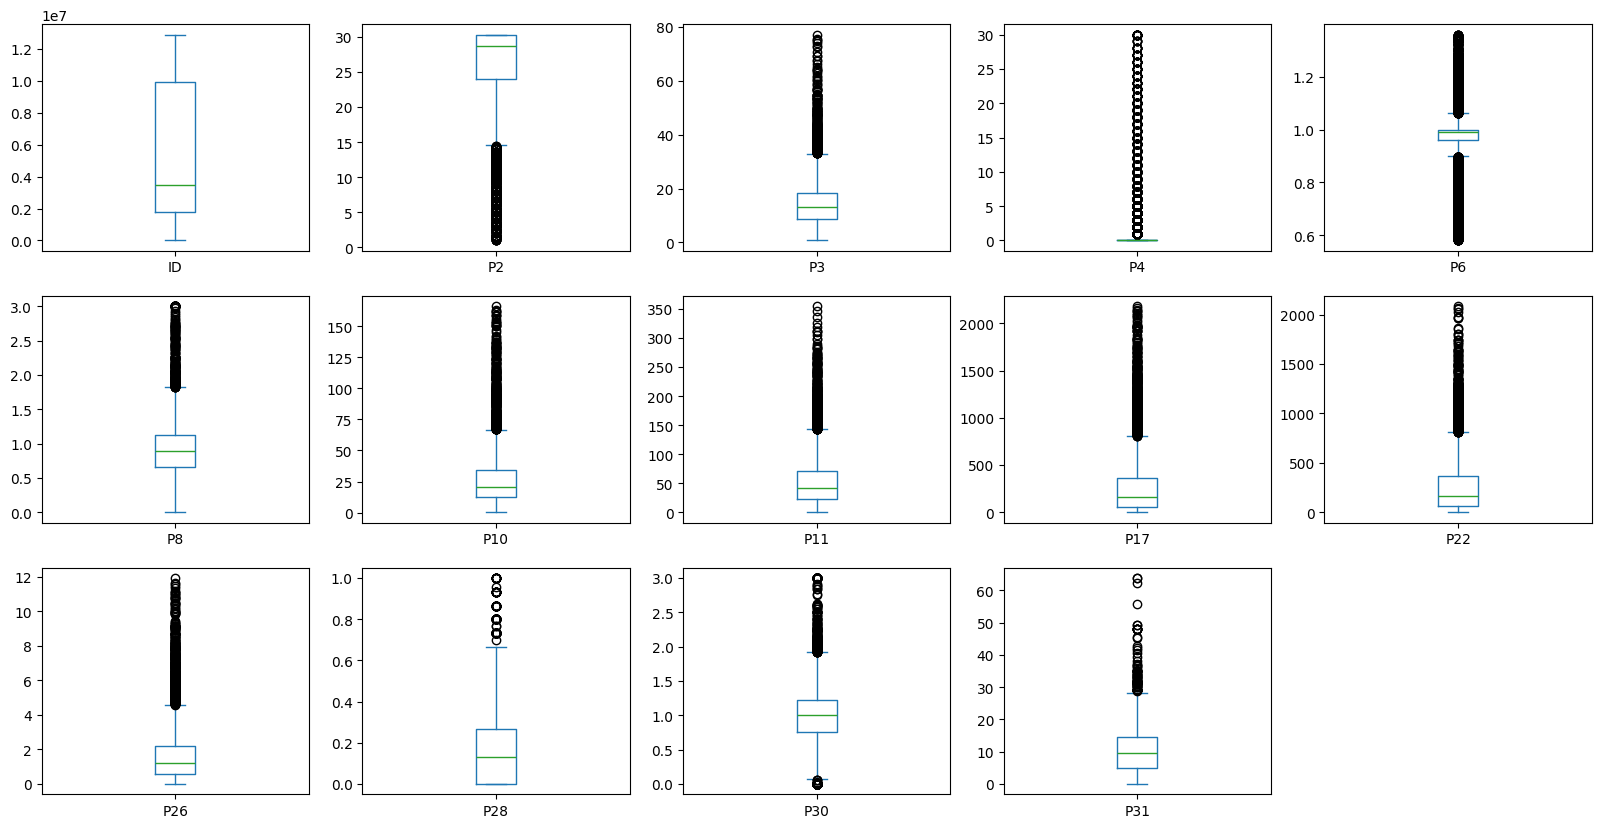

In [69]:
features_clean["train"].plot(kind='box', subplots=True, layout=(3, 5), figsize=(20, 10))
plt.show()

In [70]:
features_clean["train"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 8954 entries, 0 to 9998
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      8954 non-null   float64
 1   P2      8954 non-null   float64
 2   P3      8954 non-null   float64
 3   P4      8954 non-null   float64
 4   P6      8954 non-null   float64
 5   P8      8954 non-null   float64
 6   P10     8954 non-null   float64
 7   P11     8954 non-null   float64
 8   P17     8954 non-null   float64
 9   P22     8954 non-null   float64
 10  P26     8954 non-null   float64
 11  P28     8954 non-null   float64
 12  P30     8954 non-null   float64
 13  P31     8954 non-null   float64
dtypes: float64(14)
memory usage: 1.0 MB


Standardizing our data

In [71]:
feature_scaler = MinMaxScaler()
features_scaled = {
    "train": pd.DataFrame(feature_scaler.fit_transform(features_clean["train"]), columns=columns),
    "test": pd.DataFrame(feature_scaler.transform(features_clean['test']), columns=columns)
}

Using gridsearch to select hyperparameters.

In [72]:
model_types = ["Random forest", "Logistic Regression", "SVM"]

algorithm_parameters = {
    "Random forest": {
        "n_estimators": range(100, 200, 20),
        "min_samples_split": [3, 10, 50]
    },
    "SVM":{
        "kernel": ("poly", "rbf", "sigmoid"),
        "degree": range(3, 6),
        "gamma": ("scale", "auto")
    },
    "Logistic Regression": {
        "penalty": ("l2", None)
    }
}

predictions = {model_type: np.empty(0) for model_type in model_types}

Training our models:

In [73]:
random_forest = RandomForestClassifier()
random_forest_clf = GridSearchCV(random_forest, algorithm_parameters["Random forest"])

random_forest_clf.fit(features_scaled["train"], targets_clean["train"].to_numpy())
predictions["Random forest"] = random_forest_clf.predict(features_scaled["test"]).reshape(-1, 1)

In [74]:
logistic_regression = LogisticRegression()
logistic_regression_clf = GridSearchCV(logistic_regression, algorithm_parameters["Logistic Regression"])

logistic_regression_clf.fit(features_scaled["train"], targets_clean["train"].to_numpy())
predictions["Logistic Regression"] = logistic_regression_clf.predict(features_scaled["test"]).reshape(-1, 1)

In [ ]:
svm = SVC()
svm_clf = GridSearchCV(svm, algorithm_parameters["SVM"])

svm_clf.fit(features_scaled["train"], targets_clean["train"].to_numpy())
predictions["SVM"] = svm_clf.predict(features_scaled["test"]).reshape(-1, 1)

In [ ]:
for model_type in model_types:
    print(model_type)
    print(classification_report(targets_clean["test"], predictions[model_type]))

Random forest
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      5000
           1       0.82      0.80      0.81      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

Logistic Regression
              precision    recall  f1-score   support

           0       0.68      0.72      0.70      5000
           1       0.70      0.66      0.68      5000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000

SVM
              precision    recall  f1-score   support

           0       0.67      0.73      0.70      5000
           1       0.70      0.64      0.67      5000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68   

Random forest
Logistic Regression
SVM


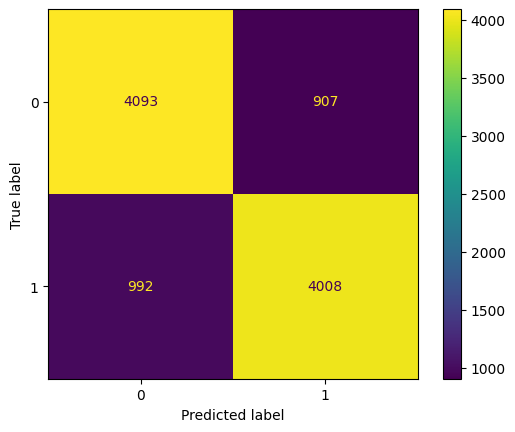

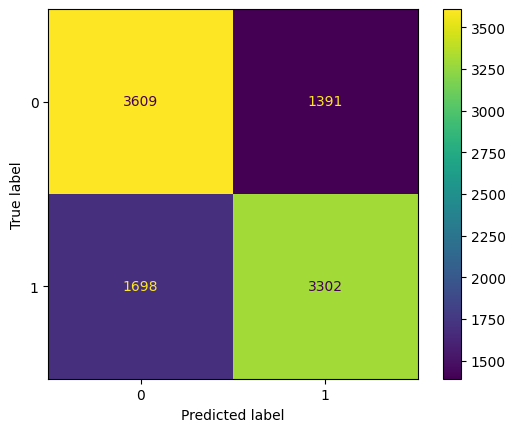

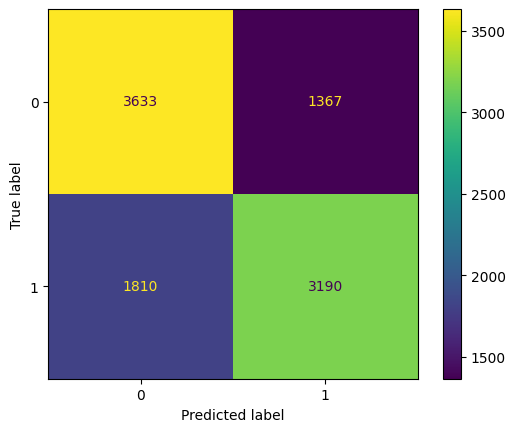

In [ ]:
for model_type in model_types:
    print(model_type)
    ConfusionMatrixDisplay.from_predictions(targets_clean["test"], predictions[model_type])

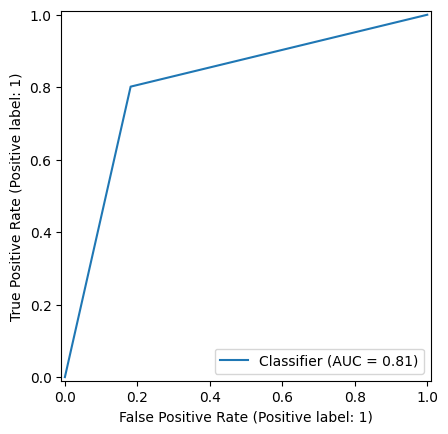

In [ ]:
RocCurveDisplay.from_predictions(targets_clean["test"], predictions["Random forest"])
plt.show()

Let's see the most important features in our data.

In [ ]:
random_forest_clf.best_estimator_

RandomForestClassifier(min_samples_split=50, n_estimators=140)

In [ ]:
random_forest = RandomForestClassifier(min_samples_split=50, n_estimators=140)
random_forest.fit(features_scaled["train"], targets_clean["train"].to_numpy())

RandomForestClassifier(min_samples_split=50, n_estimators=140)

In [ ]:
result = permutation_importance(
    random_forest, features_scaled["test"], targets_clean["test"], n_repeats=10, random_state=42, n_jobs=2
)

forest_importances = pd.Series(result.importances_mean, index=features_scaled["test"].columns)

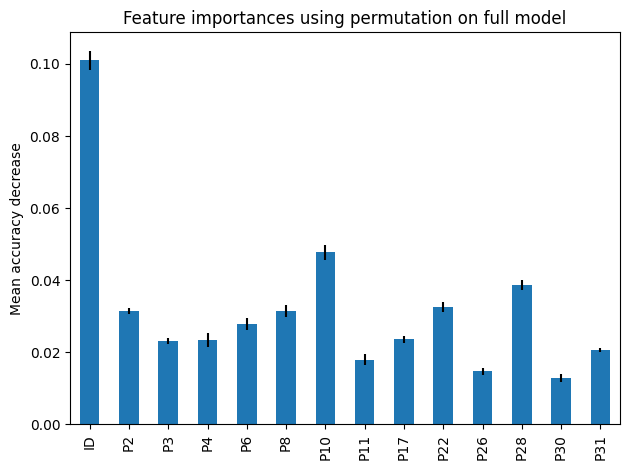

In [ ]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

In [ ]:
results = pd.Series(predictions["Random forest"].flatten())
results.to_excel("data/Task2_predictions.xlsx")

0       1
1       0
2       0
3       0
4       0
       ..
9995    1
9996    1
9997    0
9998    1
9999    1
Length: 10000, dtype: int64